In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from util.load import DataLoader
from itertools import combinations

In [2]:
dataloader = DataLoader(data_dir="../data")
ticker = "kxhighny"
max_days = 200
full_df = dataloader.load_consolidated_daily_data(
    ticker, max_days=max_days, type_="processed"
)
daily_df = dataloader.load_daily_data(ticker, max_days=max_days, type_="processed")
full_df.drop(columns=["time", "ticker", "trade_id"]).head()

Loading kxhighny for 2025-05-26: 100%|██████████| 200/200 [00:01<00:00, 189.66it/s]


,time_to_strike,count,shift,kalshi_fair,yes_price,no_price,taker_side,day_forecast_high,day_forecast_strike_dev,current_forecast_strike_dev,...,hour_forecast_rain,strike_m_5.0,strike_m_3.0,strike_m_1.0,strike_p_1.0,strike_p_3.0,strike_p_5.0,impact,result,outcome
0,131771.383,10,-1.0,65.500,18,82,1,69.6,4.1,4.8,...,0.0,0,0,18,0,0,0,-17.000,-18,0
1,131758.321,1,3.0,68.142,35,65,1,69.6,0.1,0.8,...,0.0,0,0,18,0,35,0,64.000,65,1
2,131758.321,4,3.0,68.167,36,64,1,69.6,0.1,0.8,...,0.0,0,0,18,0,36,0,63.000,64,1
3,130746.041,16,1.0,67.830,55,45,1,69.6,2.1,2.8,...,0.0,0,0,18,55,36,0,-52.036,-55,0
4,130746.041,1,1.0,67.833,54,46,1,69.6,2.1,2.8,...,0.0,0,0,18,54,36,0,-51.000,-54,0


In [109]:
print(full_df.columns)

Index(['time', 'trade_id', 'ticker', 'time_to_strike', 'count', 'shift',
       'kalshi_fair', 'yes_price', 'no_price', 'taker_side',
       'day_forecast_high', 'day_forecast_strike_dev',
       'current_forecast_strike_dev', 'day_current_forecast_dev',
       'day_wind_gusts_max', 'day_wind_speed_max', 'day_cloud_cover_max',
       'day_cloud_cover_min', 'day_sunshine_duration', 'hour_wind_gusts',
       'hour_wind_speed', 'hour_cloud_cover', 'hour_cloud_cover_high',
       'kalshi_strike_dev', 'kalshi_day_forecast_dev',
       'day_forecast_percipitation', 'day_forecast_rain', 'hour_forecast_rain',
       'strike_m_5.0', 'strike_m_3.0', 'strike_m_1.0', 'strike_p_1.0',
       'strike_p_3.0', 'strike_p_5.0', 'impact', 'result', 'outcome'],
      dtype='object')


In [110]:
def remove_outliers(df, features, quantile_range=(0.05, 0.95)):
    return_df = df.copy()
    for f in features:
        return_df = return_df[
            (return_df[f] >= return_df[f].quantile(quantile_range[0])) & 
            (return_df[f] <= return_df[f].quantile(quantile_range[1]))
        ]
    return return_df

In [54]:
def plot_outcome_dist(df, feature, bins=100):
    feature_range = np.linspace(
        df[feature].min(),
        df[feature].max(),
        bins + 1
    )
    x, y = [], []
    for i in range(1, len(feature_range)):
        lower_bound = feature_range[i-1]
        upper_bound = feature_range[i]
        subset = df[
            (df[feature] >= lower_bound) & 
            (df[feature] <= upper_bound)
        ]
        x.append((lower_bound + upper_bound) / 2)
        y.append(subset['outcome'].mean())
    plt.plot(x, y)
    plt.xlabel(feature)
    plt.ylabel("Outcome Probability")
    plt.title("Outcome Probability vs " + feature)
    plt.show()

In [68]:
df = full_df[
    (full_df['time_to_strike'] < 60000) &
    (full_df['yes_price'] > 2) & 
    (full_df['yes_price'] < 98)
]
df = remove_outliers(df, ["day_forecast_strike_dev", "current_forecast_strike_dev", 'day_sunshine_duration'])

[ 4.87773436e-01  1.87410741e-01  2.65981103e-04  0.00000000e+00
  0.00000000e+00  1.66201031e-02 -0.00000000e+00 -3.55307912e-02
 -0.00000000e+00 -8.73761291e-02  1.46415538e-02  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -3.37988103e-07]


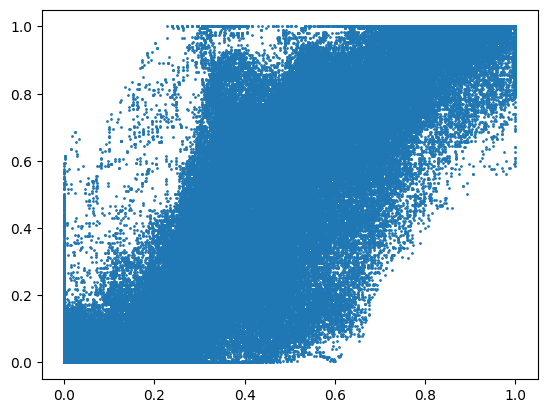

In [106]:
from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, QuantileTransformer


x = df[['yes_price', 'day_forecast_strike_dev', 'time_to_strike', 'count']]
x = StandardScaler().fit_transform(x)
poly = PolynomialFeatures(degree=2)

knn = KNeighborsClassifier(n_neighbors=200)
knn.fit(x, df['outcome'])

y_neighbors = knn.predict_proba(x)[:, 1]


x_poly = poly.fit_transform(x)

model = Lasso(alpha=0.01, fit_intercept=False)
model.fit(x_poly, y_neighbors)
print(model.coef_)

y_lasso = np.clip(model.predict(x_poly), 0, 1)

plt.scatter(y_lasso, y_neighbors, s=1)
plt.show()


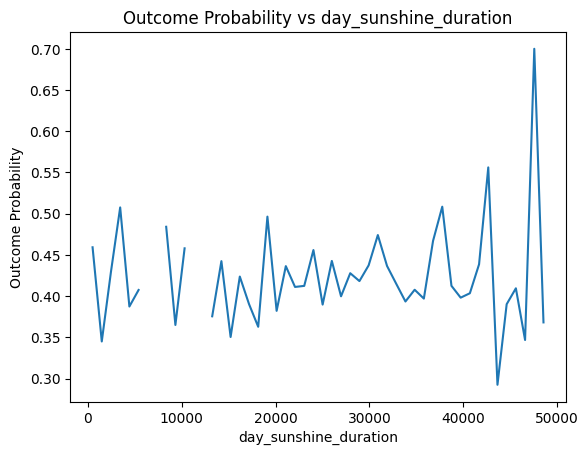

In [66]:
plot_outcome_dist(df, "day_sunshine_duration", bins=50)

<Axes: >

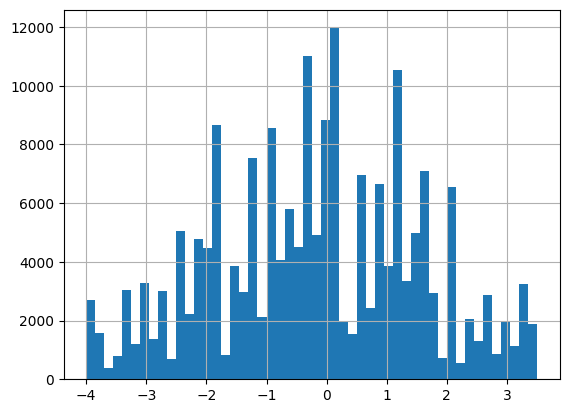

In [39]:
df['day_forecast_strike_dev'].hist(bins=50)

<Axes: >

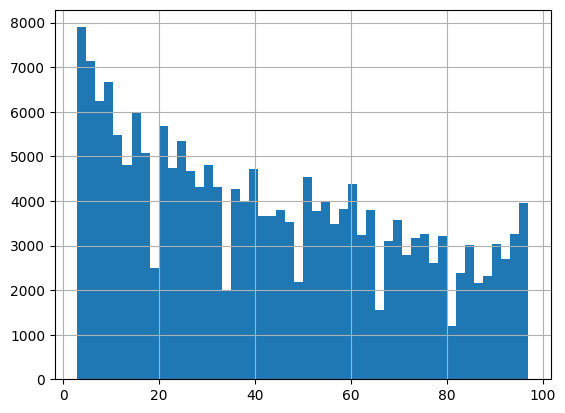

In [40]:
df['yes_price'].hist(bins=50)

<Axes: >

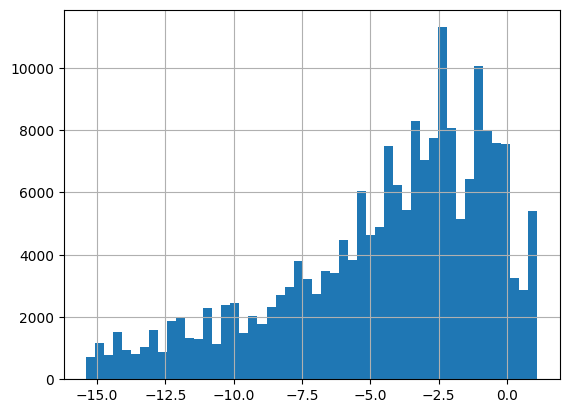

In [41]:
df['current_forecast_strike_dev'].hist(bins=50)

In [123]:
forecast_range = np.linspace(
    df['day_forecast_strike_dev'].min(), 
    df['day_forecast_strike_dev'].max(), 
    101
)
price_range = np.linspace(
    df['yes_price'].min(),
    df['yes_price'].max(),
    101
)

forecast_buckets = []
price_buckets = []
for i in range(1, len(forecast_range)):
    forecast_buckets.append((forecast_range[i-1], forecast_range[i]))

for i in range(1, len(price_range)):
    price_buckets.append((price_range[i-1], price_range[i]))


x, y = [], []
for (fl, fu) in forecast_buckets:
    for (pl, pu) in price_buckets:
        outcomes = df[
            (df['day_forecast_strike_dev'] >= fl) & 
            (df['day_forecast_strike_dev'] <= fu) &
            (df['yes_price'] >= pl) & 
            (df['yes_price'] <= pu)
        ]['outcome']
        if len(outcomes) > 50:
            x.append([(fl + fu) / 2, (pl + pu) / 2])
            y.append(outcomes.mean())


from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=1)
# x = poly.fit_transform(x)

lin = LinearRegression()
lin.fit(x, y)


LinearRegression()

In [125]:
x = np.array(x)
x

array([[-3.9625,  3.47  ],
       [-3.9625,  5.35  ],
       [-3.9625,  6.29  ],
       ...,
       [ 3.4625,  6.29  ],
       [ 3.4625,  7.23  ],
       [ 3.4625,  8.17  ]], shape=(1198, 2))

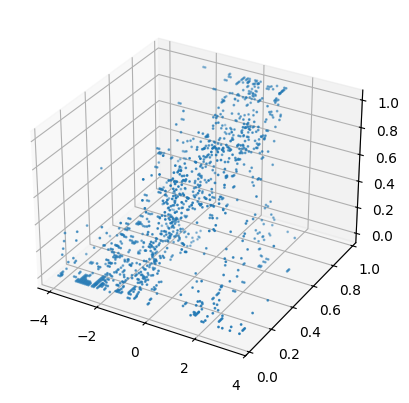

In [127]:
# create 3d plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[:, 0], x[:, 1] / 100, y, s=1)
plt.show()


<Axes: xlabel='yes_price', ylabel='day_forecast_strike_dev'>

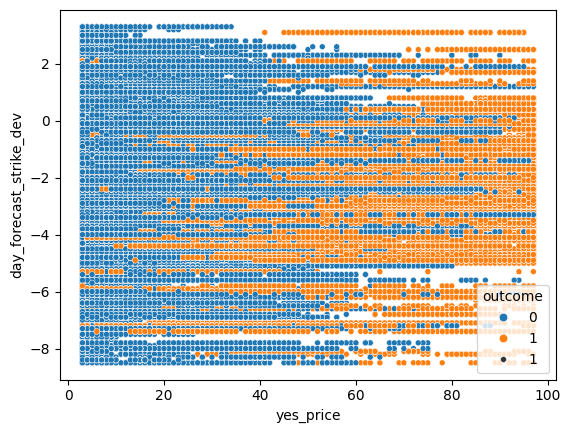

In [24]:
sns.scatterplot(
    df,
    x='yes_price',
    y='day_forecast_strike_dev',
    size=1,
    hue='outcome'
)

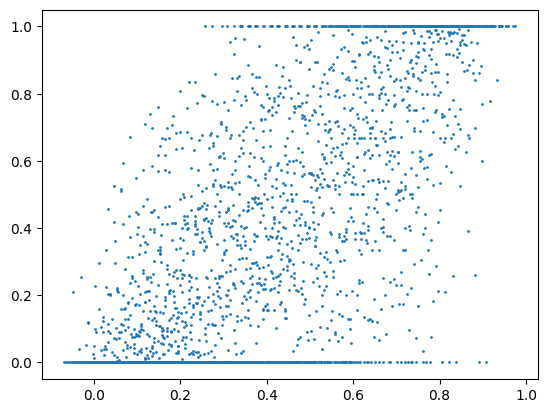

0.45925972394822


In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

y_pred = lin.predict(x)

plt.scatter(y_pred, y, s=1)
plt.show()
print(r2_score(y, y_pred))

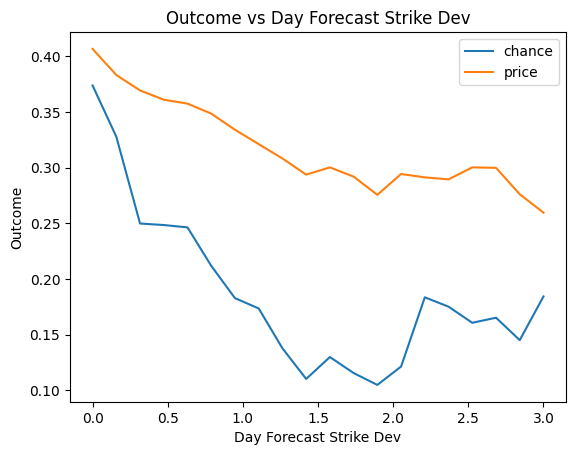

In [29]:
T = np.linspace(0, 3, 20)

y = []
y2 = []
for t in T:
    y.append(df[abs(df['day_forecast_strike_dev'] - t) < 1]['outcome'].mean())
    y2.append(df[abs(df['day_forecast_strike_dev'] - t) < 1]['yes_price'].mean())

y2 = np.array(y2)
y2 /= 100
plt.plot(T, y, label="chance")
plt.plot(T, y2, label='price')


plt.xlabel("Day Forecast Strike Dev")
plt.ylabel("Outcome")
plt.title("Outcome vs Day Forecast Strike Dev")
plt.legend()
plt.show()

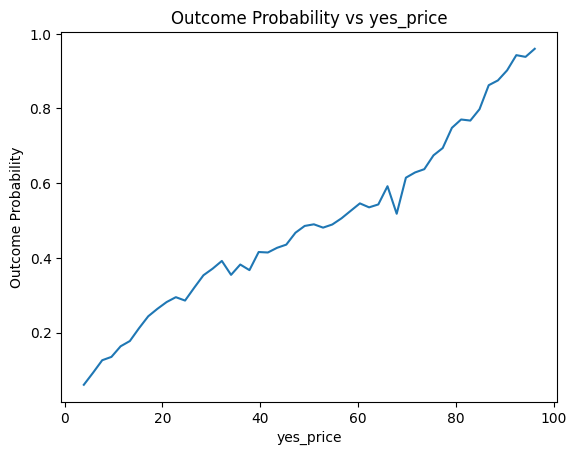

In [67]:
plot_outcome_dist(df, "yes_price", bins=50)

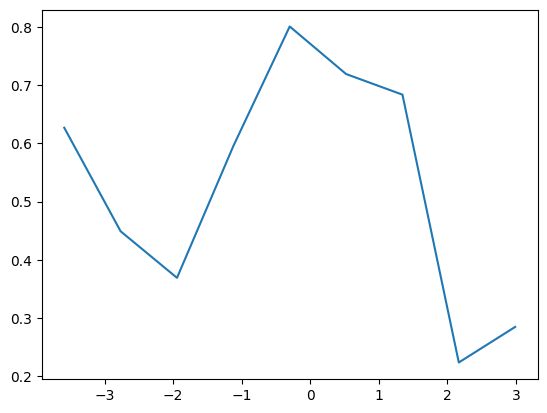

In [115]:
reg = df[(df['yes_price'] > 60) & (df['yes_price'] < 80)]
forecast_range = np.linspace(
    reg['day_forecast_strike_dev'].min(), 
    reg['day_forecast_strike_dev'].max(), 
    10
)

x = []
y = []
for i in range(1, len(forecast_range)):
    x.append((forecast_range[i-1] + forecast_range[i]) / 2)
    y.append(reg[(reg['day_forecast_strike_dev'] >= forecast_range[i-1]) & (reg['day_forecast_strike_dev'] <= forecast_range[i])]['outcome'].mean())

plt.plot(x, y)
plt.show()


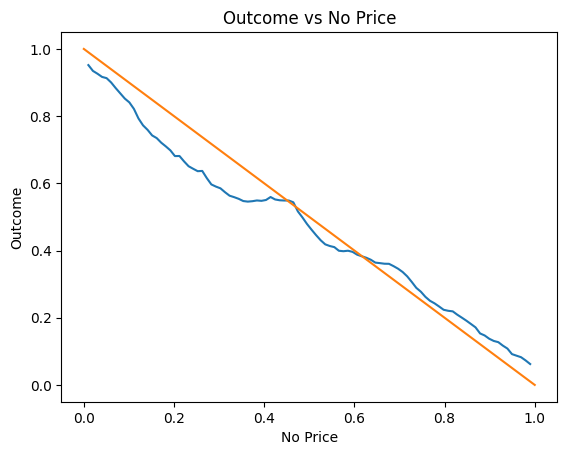

In [28]:
T = np.linspace(0, 100, 100)

base = np.array([x / 100 for x in T])
y = []
for t in T:
    y.append(df[abs(df['no_price'] - t) < 3]['outcome'].mean())
plt.plot(base, y)
plt.plot(base, np.array([1 - x / 100 for x in T]))
plt.xlabel("No Price")
plt.ylabel("Outcome")
plt.title("Outcome vs No Price")
plt.show()
